In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df= pd.read_csv('german_credit_data.csv')

In [ ]:
# Handling missing values

df['Saving accounts'] = df['Saving accounts'].fillna('no_account')
df['Checking account'] = df['Checking account'].fillna('no_account')

In [ ]:
df.isnull().sum()

,0
Age,0
Sex,0
Job,0
Housing,0
Saving accounts,0
Checking account,0
Credit amount,0
Duration,0
Purpose,0
Risk,0


In [ ]:
# Target Encoding

df['Risk'] = df['Risk'].map({'good': 0, 'bad': 1})
df['Risk'].value_counts()

,count
Risk,
0,604
1,396


In [ ]:
df.select_dtypes(include='object').columns

Index(['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose'], dtype='object')

In [ ]:
# Applying one-hot encoding to categorical variables

df = pd.get_dummies(df, drop_first=True)
df.head()

,Age,Job,Credit amount,Duration,Risk,Sex_male,Housing_own,Housing_rent,Saving accounts_moderate,Saving accounts_no_account,...,Checking account_moderate,Checking account_no_account,Checking account_rich,Purpose_car,Purpose_domestic appliances,Purpose_education,Purpose_furniture,Purpose_radio/TV,Purpose_repairs,Purpose_vacation/others
0,56,1,6745,22,0,True,True,False,False,False,...,True,False,False,True,False,False,False,False,False,False
1,69,2,10437,70,0,False,False,False,True,False,...,True,False,False,True,False,False,False,False,False,False
2,46,3,9763,8,0,True,True,False,False,False,...,False,False,False,True,False,False,False,False,False,False
3,32,1,18964,70,1,False,True,False,True,False,...,False,False,False,False,False,False,False,True,False,False
4,60,2,17650,14,0,True,True,False,True,False,...,False,False,False,False,True,False,False,False,False,False


In [ ]:
# Seperating features and target

X = df.drop('Risk', axis=1)
y = df['Risk']

In [ ]:
# train test split

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify = y)

In [ ]:
# Scaling

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# 1.4 Feature Engineering

In [ ]:
# Credit_to_Duration_Ratio: it measures the monthly repayment pressure of the borrower. A high value indicates larger loan burden per month, which may increase the probability of default.

df['Credit_to_Duration_Ratio'] = df['Credit amount'] / df['Duration']


In [ ]:
# Age_Group: Categorises borrowers into life-stage segments. Younger borrowers may have unstable income and higher risk, while older ones tend to be financially stable.

df['Age_Group'] = pd.cut(df['Age'], bins=[18, 25, 35, 50, 100], labels=['18-25', '26-35', '36-50', '50+'])

In [ ]:
# High_Risk_Purpose: binary feature that flags loan purposes historically associated with higher financial uncertainity.
#                     Certain loan purposes may indicate to higher risk default due to car loans, education loans etc.

High_Risk = ['car', 'education','repairs' ]
df['High_Risk_Purpose'] = (df[['Purpose_car', 'Purpose_education', 'Purpose_repairs']].sum(axis=1) > 0).astype(int)

In [ ]:
# Account_Stability: captures the financial strength of a borrower by combining savings and checking account categories.

df['Account_Stability'] = (df[['Saving accounts_rich', 'Saving accounts_quite rich', 'Checking account_rich']].sum(axis=1) > 0).astype(int)

In [ ]:
# 2.1 a) Logistic Regression

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(random_state=42))
])
lr_pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier', LogisticRegression(random_state=42))])

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

y_pred = lr_pipeline.predict(X_test)
y_proba = lr_pipeline.predict_proba(X_test)[:, 1]

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Logistic Regression Accuracy: 0.795
ROC-AUC: 0.895595773616487

Confusion Matrix:
 [[103  18]
 [ 23  56]]

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.85      0.83       121
           1       0.76      0.71      0.73        79

    accuracy                           0.80       200
   macro avg       0.79      0.78      0.78       200
weighted avg       0.79      0.80      0.79       200



In [ ]:
# Logistic Regression provides a strong baseline with 79.5% accuracy and ROC-AUC~0.895, indicating
# good seperation between good and bad credit risk. The model achieves 0.72 recall for the bad class, identifying 72% of defaulters.

In [ ]:
# Decision Tree

from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)
y_proba_dt = dt_model.predict_proba(X_test)[:, 1]

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_dt))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.755
ROC-AUC: 0.733811068103358

Confusion Matrix:
 [[101  20]
 [ 29  50]]

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.83      0.80       121
           1       0.71      0.63      0.67        79

    accuracy                           0.76       200
   macro avg       0.75      0.73      0.74       200
weighted avg       0.75      0.76      0.75       200



In [ ]:
# The Decision Tree model was trained as a non-linear classifier.
# While it can capture complex relationships, it may overfit the training data if not regularised properly.
# Hyperparameters such as max_depth and min_samples_leaf were adjusted to control model complexity.

In [ ]:
# Random Forest

from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, f1_score

y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))
print("Baseline F1 Score:", f1_score(y_test, y_pred_rf))


Random Forest Accuracy: 0.83
ROC-AUC: 0.9260382885239041

Confusion Matrix:
 [[109  12]
 [ 22  57]]

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.90      0.87       121
           1       0.83      0.72      0.77        79

    accuracy                           0.83       200
   macro avg       0.83      0.81      0.82       200
weighted avg       0.83      0.83      0.83       200

Baseline F1 Score: 0.7702702702702703


In [ ]:
# Random Forest was trained as an ensemble of decision trees to reduce overfitting and capture
# non-linear relationships. Compared to a single Decision Tree, it improves generalisation by
# averaging predictions across multiple trees.
# feature importance also provides insight into which attributes contribute most.

In [ ]:
# XGBoost

from xgboost import XGBClassifier
xgb_model = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, f1_score

y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_xgb))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))
print("Baseline F1 Score:", f1_score(y_test, y_pred_xgb))

XGBoost Accuracy: 0.865
ROC-AUC: 0.9346165916936918

Confusion Matrix:
 [[111  10]
 [ 17  62]]

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.92      0.89       121
           1       0.86      0.78      0.82        79

    accuracy                           0.86       200
   macro avg       0.86      0.85      0.86       200
weighted avg       0.86      0.86      0.86       200

Baseline F1 Score: 0.8211920529801324


In [ ]:
# XGBoost is an ensemble method that builds decision trees sequentially, which each new tree
# focuses on correcting the errors made by the previous trees. This is powerful for tabular
# datasets because it can capture non linear relationships and feature interactions while
# controlling overfitting through regularisation.

In [ ]:
# 2.2 Hyperparameter Tuning
# GridSearch (Random Forest)

from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=1
)
grid_search.fit(X_train, y_train)
print(f"Best params: {grid_search.best_params_}")
print(f"Best CV score: {grid_search.best_score_:.4f}")

# Tuning

best_rf = grid_search.best_estimator_
y_pred_rf_tuned = best_rf.predict(X_test)
print("F1:", f1_score(y_test, y_pred))
print("F1 (Tuned):", f1_score(y_test, y_pred_rf_tuned))




Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best params: {'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 50}
Best CV score: 0.8211
F1: 0.7320261437908496
F1 (Tuned): 0.7808219178082192


In [ ]:
# GridSearch (Logistic Regression)

param_grid = {
    'classifier__C': [0.01, 0.1, 1, 10, 100],
    'classifier__penalty': ['l2'],
    'classifier__solver': ['liblinear', 'lbfgs']
}

grid_lr = GridSearchCV(
    lr_pipeline, param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=1
)

grid_lr.fit(X_train, y_train)

print("Best Parameters:", grid_lr.best_params_)
print("Best F1 Score:", grid_lr.best_score_)

# Tuning

best_lr = grid_lr.best_estimator_

y_pred_lr_tuned = best_lr.predict(X_test)
print("F1:", f1_score(y_test, y_pred))
print("F1 (Tuned):", f1_score(y_test, y_pred_lr_tuned))

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Parameters: {'classifier__C': 0.1, 'classifier__penalty': 'l2', 'classifier__solver': 'liblinear'}
Best F1 Score: 0.7586567925802798
F1: 0.7320261437908496
F1 (Tuned): 0.7284768211920529


In [ ]:
# GridSearch (XGBoost)

from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

param_grid = {
    "n_estimators": [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.1],
}
grid_search_xgb = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss'),
    param_grid, cv=5, scoring='f1', n_jobs=-1,verbose=1)

grid_search_xgb.fit(X_train, y_train)

print("Best XGBoost params:", grid_search_xgb.best_params_)
print("Best XGBoost F1 score:", grid_search_xgb.best_score_)

# Tuning

best_xgb = grid_search_xgb.best_estimator_
y_pred_xgb_tuned = best_xgb.predict(X_test)

print("F1:", f1_score(y_test, y_pred_xgb))
print("F1 (Tuned):", f1_score(y_test, y_pred_xgb_tuned))

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best XGBoost params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}
Best XGBoost F1 score: 0.833585567835699
F1: 0.8211920529801324
F1 (Tuned): 0.7919463087248322


In [ ]:
# Results

# Random Forest : Baseline F1 Score = 0.7320
#                 Tuned F1 Score = 0.7808

# Logistic Regression : Baseline Test F1 = 0.72
#                       Tuned F1 Score = 0.73

# XGBoost : Baseline Test F1 = 0.8378
#           Tuned F1 Score = 0.7919

# While Logistic Regression shows stable performance, Random Forest significantly improved after
# hyperparameter tuning. However, XGBoost achieved the best performance  after hyperparameter
# tuning. Therefore, XGBoost model is to be selected as FINAL model  due to its superior
# predictivwe performance

In [ ]:
# 2.3 Experiment Tracking with MLflow

In [ ]:
!pip install mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 57.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 61.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 59.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.1/197.1 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 811.1/811.1 kB 36.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 14.9 MB/s eta 0:00:00


In [ ]:
# Random Forest

import mlflow
import mlflow.sklearn
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

mlflow.set_experiment("credit_risk_classification")

best_rf = grid_search.best_estimator_
y_pred_rf_tuned = best_rf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_rf_tuned)
precision = precision_score(y_test, y_pred_rf_tuned)
recall = recall_score(y_test, y_pred_rf_tuned)
f1 = f1_score(y_test, y_pred_rf_tuned)

with mlflow.start_run(run_name="random_forest_tuned"):

  for param, value in grid_search.best_params_.items():
    mlflow.log_param(param, value)
    mlflow.log_param("model_type", "Random Forest")
    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1_score", f1)
    # confusion matrix

    cm_rf = confusion_matrix(y_test, y_pred_rf_tuned)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix - Random Forest')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')

    plt.savefig('cm_rf.png')
    plt.close()
    mlflow.log_artifact('cm_rf.png')
    # log model
    mlflow.sklearn.log_model(best_rf, "model")

2026/02/26 15:04:50 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/02/26 15:04:50 INFO mlflow.store.db.utils: Updating database tables
2026/02/26 15:04:56 INFO mlflow.tracking.fluent: Experiment with name 'credit_risk_classification' does not exist. Creating a new experiment.
2026/02/26 15:04:57 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/26 15:04:57 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/02/26 15:05:11 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/26 15:05:11 WARNING mlflow.sklearn: Saving scikit-learn models in the p

In [ ]:
# Logistic Regression

import mlflow
import mlflow.sklearn
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

mlflow.set_experiment("credit_risk_classification")

best_lr = grid_lr.best_estimator_
y_pred_lr_tuned = best_lr.predict(X_test)

accuracy_lr = accuracy_score(y_test, y_pred_lr_tuned)
precision_lr = precision_score(y_test, y_pred_lr_tuned)
recall_lr = recall_score(y_test, y_pred_lr_tuned)
f1_lr = f1_score(y_test, y_pred_lr_tuned)

with mlflow.start_run(run_name="logistic_regression_tuned"):

  for param, value in grid_lr.best_params_.items():
    mlflow.log_param(param, value)
    mlflow.log_param("model_type", "Logistic Regression")
    mlflow.log_metric("accuracy", accuracy_lr)
    mlflow.log_metric("precision", precision_lr)
    mlflow.log_metric("recall", recall_lr)
    mlflow.log_metric("f1_score", f1_lr)
    #confusion matrix
    cm_lr = confusion_matrix(y_test, y_pred_lr_tuned)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix - Logistic Regression Tuned')
    plt.xlabel('Predicted')
    plt.ylabel("Actual")
    plt.savefig('cm_logistic.png')
    plt.close()
    mlflow.log_artifact('cm_logistic.png')
    #log model
    mlflow.sklearn.log_model(best_lr, "model")


2026/02/26 15:05:25 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/26 15:05:25 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/02/26 15:05:35 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/26 15:05:35 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_p

In [ ]:
# XGBoost

import mlflow
import mlflow.sklearn

best_xgb = grid_search_xgb.best_estimator_

y_pred_xgb_tuned = best_xgb.predict(X_test)

accuracy_xgb = accuracy_score(y_test, y_pred_xgb_tuned)
precision_xgb = precision_score(y_test, y_pred_xgb_tuned)
recall_xgb = recall_score(y_test, y_pred_xgb_tuned)
f1_xgb = f1_score(y_test, y_pred_xgb_tuned)

with mlflow.start_run(run_name="xgboost_tuned"):

  for param, value in grid_search_xgb.best_params_.items():
    mlflow.log_param(param, value)

    mlflow.log_param("model_type", "XGBoost")

    mlflow.log_metric("accuracy", accuracy_xgb)
    mlflow.log_metric("precision", precision_xgb)
    mlflow.log_metric("recall", recall_xgb)
    mlflow.log_metric("f1_score", f1_xgb)
   # confusion matrix
    cm = confusion_matrix(y_test, y_pred_xgb_tuned)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix - XGBoost Tuned')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.savefig('confusion _matrix.png')
    mlflow.log_artifact('confusion _matrix.png')
    plt.close()

     # log model
    mlflow.sklearn.log_model(best_xgb, "xgboost_model")


2026/02/26 15:06:07 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/26 15:06:08 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/02/26 15:06:15 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/26 15:06:15 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_p

In [ ]:
import os, joblib

BASE = "/content/drive/MyDrive/T2_Project_Tanmay"
MODEL_DIR = f"{BASE}/Models"
os.makedirs(MODEL_DIR, exist_ok=True)

joblib.dump(lr_pipeline, f"{MODEL_DIR}/logistic_regression.pkl")
joblib.dump(dt_model,     f"{MODEL_DIR}/decision_tree.pkl")
joblib.dump(rf_model,     f"{MODEL_DIR}/random_forest.pkl")
joblib.dump(xgb_model,    f"{MODEL_DIR}/xgboost.pkl")

!ls -la "$MODEL_DIR"



total 2807
-rw------- 1 root root   22201 Feb 26 15:47 decision_tree.pkl
-rw------- 1 root root    2017 Feb 26 15:47 logistic_regression.pkl
-rw------- 1 root root 2658585 Feb 26 15:47 random_forest.pkl
-rw------- 1 root root  190418 Feb 26 15:47 xgboost.pkl


In [ ]:
os.listdir(f"{BASE}/Models")

['logistic_regression.pkl',
 'decision_tree.pkl',
 'random_forest.pkl',
 'xgboost.pkl']

Searching for T2_Project_Tanmay in Drive...
/content/drive/MyDrive/T2_Project_Tanmay
/content/drive/MyDrive/Colab Notebooks/T2_Project_Tanmay

Searching for .pkl files...
/content/drive/MyDrive/T2_Project_Tanmay/Models/logistic_regression.pkl
/content/drive/MyDrive/T2_Project_Tanmay/Models/decision_tree.pkl
/content/drive/MyDrive/T2_Project_Tanmay/Models/random_forest.pkl
/content/drive/MyDrive/T2_Project_Tanmay/Models/xgboost.pkl


T2_Project_Tanmay


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve, auc
import pandas as pd

BASE = "/content/drive/MyDrive/T2_Project_Tanmay"
VIS_DIR = f"{BASE}/Visualizations"
os.makedirs(VIS_DIR, exist_ok=True)

print("Saving plots to:", VIS_DIR)

Saving plots to: /content/drive/MyDrive/T2_Project_Tanmay/Visualizations


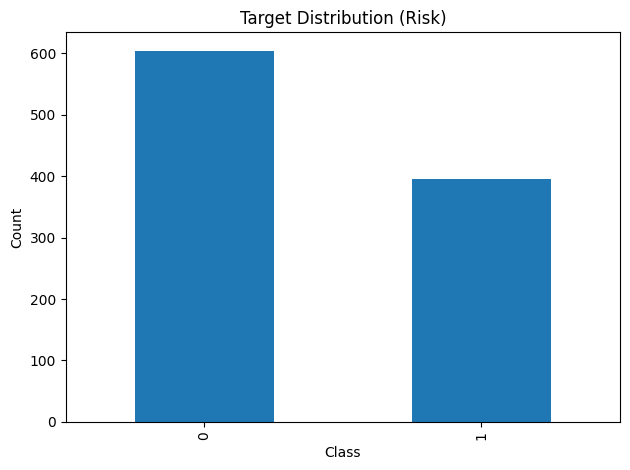

In [ ]:
target_counts = pd.Series(y).value_counts().sort_index()

plt.figure()
target_counts.plot(kind="bar")
plt.title("Target Distribution (Risk)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(f"{VIS_DIR}/target_distribution.png", dpi=200)
plt.show()

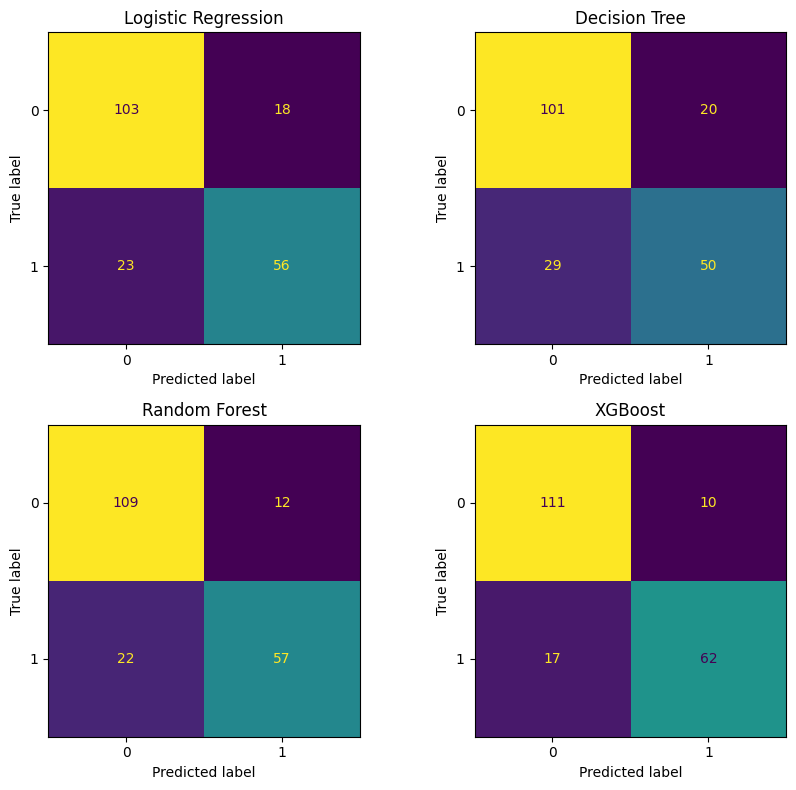

In [ ]:
from sklearn.metrics import confusion_matrix

models = {
    "Logistic Regression": lr_pipeline,
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model
}

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.ravel()

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(name)
    plt.tight_layout()
plt.savefig(f"{VIS_DIR}/confusion_matrices.png", dpi=200)
plt.show()

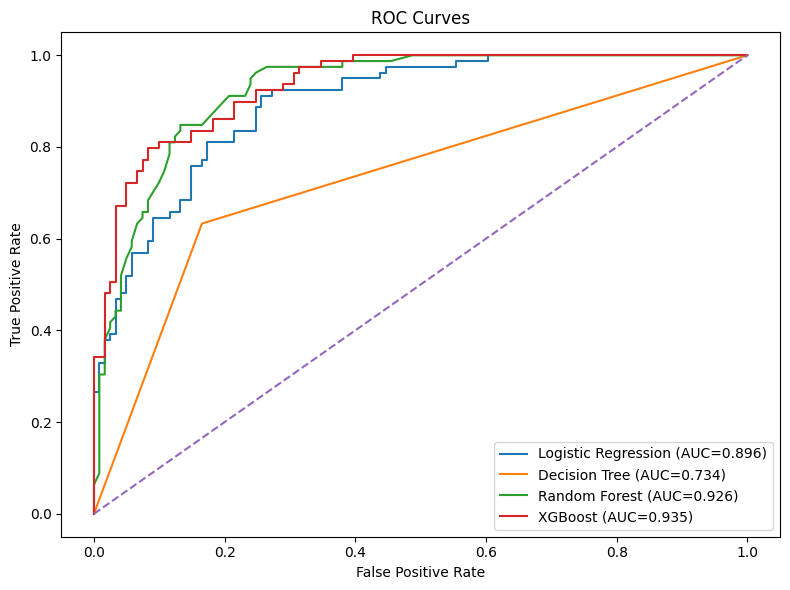

In [ ]:
plt.figure(figsize=(8,6))

for name, model in models.items():
    # probability for positive class
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")

plt.plot([0,1], [0,1], linestyle="--")
plt.title("ROC Curves")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.savefig(f"{VIS_DIR}/roc_curves.png", dpi=200)
plt.show()

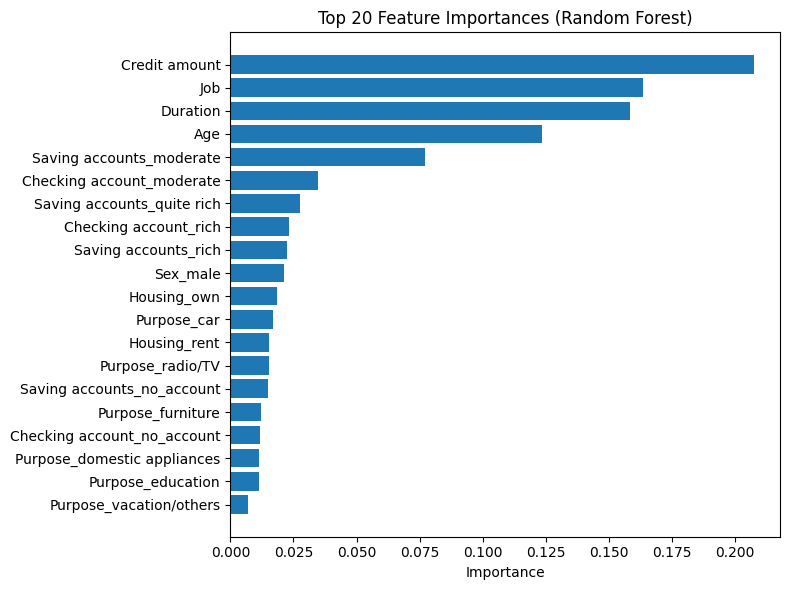

In [ ]:
try:
    feature_names = X.columns
except:
    feature_names = [f"f{i}" for i in range(X_train.shape[1])]

importances = rf_model.feature_importances_

# top 20
idx = np.argsort(importances)[-20:]

plt.figure(figsize=(8,6))
plt.barh(np.array(feature_names)[idx], importances[idx])
plt.title("Top 20 Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig(f"{VIS_DIR}/feature_importance.png", dpi=200)
plt.show()

In [ ]:
!ls -la "{VIS_DIR}"

total 368
-rw------- 1 root root  72482 Feb 26 16:07 confusion_matrices.png
-rw------- 1 root root 139109 Feb 26 16:07 feature_importance.png
-rw------- 1 root root 130986 Feb 26 16:07 roc_curves.png
-rw------- 1 root root  32927 Feb 26 16:07 target_distribution.png
